In [ ]:
from pyspark.sql import SparkSession

# Initialize the Spark Session
spark = SparkSession.builder \
    .appName("GasSensorAnalysis") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Spark started successfully!")

# Load the entire folder containing the CSV files
folder_path = "data/*.csv" 

# Read the CSVs
df = spark.read.csv(folder_path, header=True, inferSchema=True) 

print(f"Loaded {df.count()} total records from all files!")

# Show the column names
df.printSchema()

# Show the first 5 rows
df.show(5)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/09 13:24:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ Spark started successfully!


26/03/09 13:24:13 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: data/*.csv.
java.io.FileNotFoundException: File data/*.csv does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:980)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1301)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:970)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org.apache.spark.sql.execution.streaming.sinks.FileStreamSink$.hasMetadata(FileStreamSink.scala:58)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:384)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV1BatchSource(ResolveDataSource.scala:143)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource$$anonfu

✅ Loaded 3843160 total records from all files!
root
 |-- Time (s): double (nullable = true)
 |-- CO (ppm): double (nullable = true)
 |-- Humidity (%r.h.): double (nullable = true)
 |-- Temperature (C): double (nullable = true)
 |-- Flow rate (mL/min): double (nullable = true)
 |-- Heater voltage (V): double (nullable = true)
 |-- R1 (MOhm): double (nullable = true)
 |-- R2 (MOhm): double (nullable = true)
 |-- R3 (MOhm): double (nullable = true)
 |-- R4 (MOhm): double (nullable = true)
 |-- R5 (MOhm): double (nullable = true)
 |-- R6 (MOhm): double (nullable = true)
 |-- R7 (MOhm): double (nullable = true)
 |-- R8 (MOhm): double (nullable = true)
 |-- R9 (MOhm): double (nullable = true)
 |-- R10 (MOhm): double (nullable = true)
 |-- R11 (MOhm): double (nullable = true)
 |-- R12 (MOhm): double (nullable = true)
 |-- R13 (MOhm): double (nullable = true)
 |-- R14 (MOhm): double (nullable = true)

+--------+--------+----------------+---------------+------------------+------------------+---

In [ ]:
from pyspark.sql.functions import col, expr, row_number, count, isnan, when
from pyspark.sql.window import Window

# Unpivot - Convert the 14 sensor columns into 2 (Sensor_ID, Resistance)
unpivot_expr = "stack(14, " + ", ".join([f"'R{i}', `R{i} (MOhm)`" for i in range(1, 15)]) + ") as (Sensor_ID, Resistance)"

# Using backticks (`) around column names to prevent PySpark from misinterpreting dots (.)
df_melted = df.select(
    col("`Time (s)`"),
    col("`CO (ppm)`"),
    col("`Humidity (%r.h.)`"),
    col("`Temperature (C)`"),
    col("`Flow rate (mL/min)`"),
    col("`Heater voltage (V)`"),
    expr(unpivot_expr)
)

print("Unpivot complete!")

# Timestamp Normalization (Per sensor, starting 2025-09-01, 5-minute intervals)
window_spec = Window.partitionBy("Sensor_ID").orderBy(col("`Time (s)`"))

# Create row number (0, 1, 2...) for each measurement of the same sensor
df_normalized = df_melted.withColumn("row_num", row_number().over(window_spec) - 1)

# Calculate the new timestamp
df_normalized = df_normalized.withColumn(
    "Timestamp",
    expr("timestamp('2025-09-01 00:00:00') + interval 5 minutes * row_num")
).drop("row_num")

print("Timestamp normalization complete!")

# Check for Missing Values
print("Checking for missing values per column:")

missing_exprs = []
for c_name, c_type in df_normalized.dtypes:
    safe_c = f"`{c_name}`"
    
    if c_type in ('double', 'float', 'int', 'bigint'):
        # For numbers: check NaN and Null
        missing_exprs.append(count(when(isnan(col(safe_c)) | col(safe_c).isNull(), c_name)).alias(c_name))
    else:
        # For Strings: check only Null
        missing_exprs.append(count(when(col(safe_c).isNull(), c_name)).alias(c_name))

missing_counts = df_normalized.select(missing_exprs)
missing_counts.show()

# Show final result
df_normalized.show(5)

✅ Unpivot complete!
✅ Timestamp normalization complete!
🔍 Checking for missing values per column:


+--------+--------+----------------+---------------+------------------+------------------+---------+----------+---------+
|Time (s)|CO (ppm)|Humidity (%r.h.)|Temperature (C)|Flow rate (mL/min)|Heater voltage (V)|Sensor_ID|Resistance|Timestamp|
+--------+--------+----------------+---------------+------------------+------------------+---------+----------+---------+
|       0|       0|               0|              0|                 0|                 0|        0|         0|        0|
+--------+--------+----------------+---------------+------------------+------------------+---------+----------+---------+



+--------+--------+----------------+---------------+------------------+------------------+---------+----------+-------------------+
|Time (s)|CO (ppm)|Humidity (%r.h.)|Temperature (C)|Flow rate (mL/min)|Heater voltage (V)|Sensor_ID|Resistance|          Timestamp|
+--------+--------+----------------+---------------+------------------+------------------+---------+----------+-------------------+
|     0.0|     0.0|         54.6258|        25.3178|          242.5724|             0.203|      R13|   52.4943|2025-09-01 00:00:00|
|     0.0|     0.0|           57.71|          25.74|          243.7841|            0.1996|      R13|    40.016|2025-09-01 00:05:00|
|     0.0|     0.0|         51.0811|        26.1138|          244.9963|            0.8985|      R13|    0.1086|2025-09-01 00:10:00|
|     0.0|     0.0|           48.47|          24.62|          247.4926|               0.2|      R13|   49.4775|2025-09-01 00:15:00|
|     0.0|     0.0|         63.0844|        25.3805|          242.4995|     

Taking a 1% random sample to avoid memory crash (sampling)...


Sample ready! Plotting graphs...


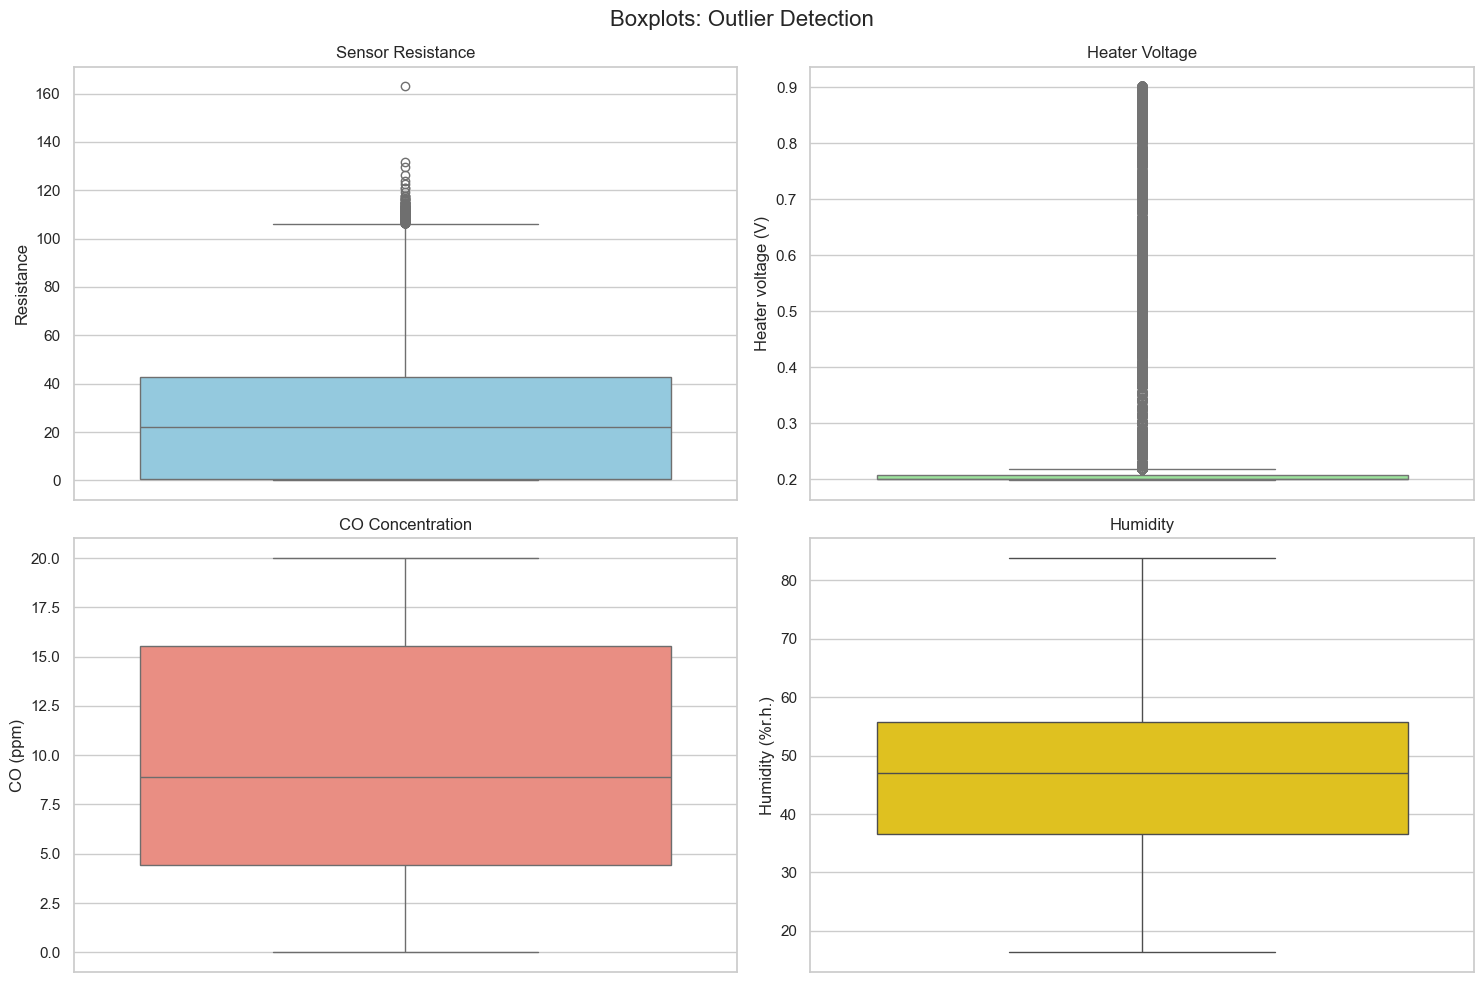

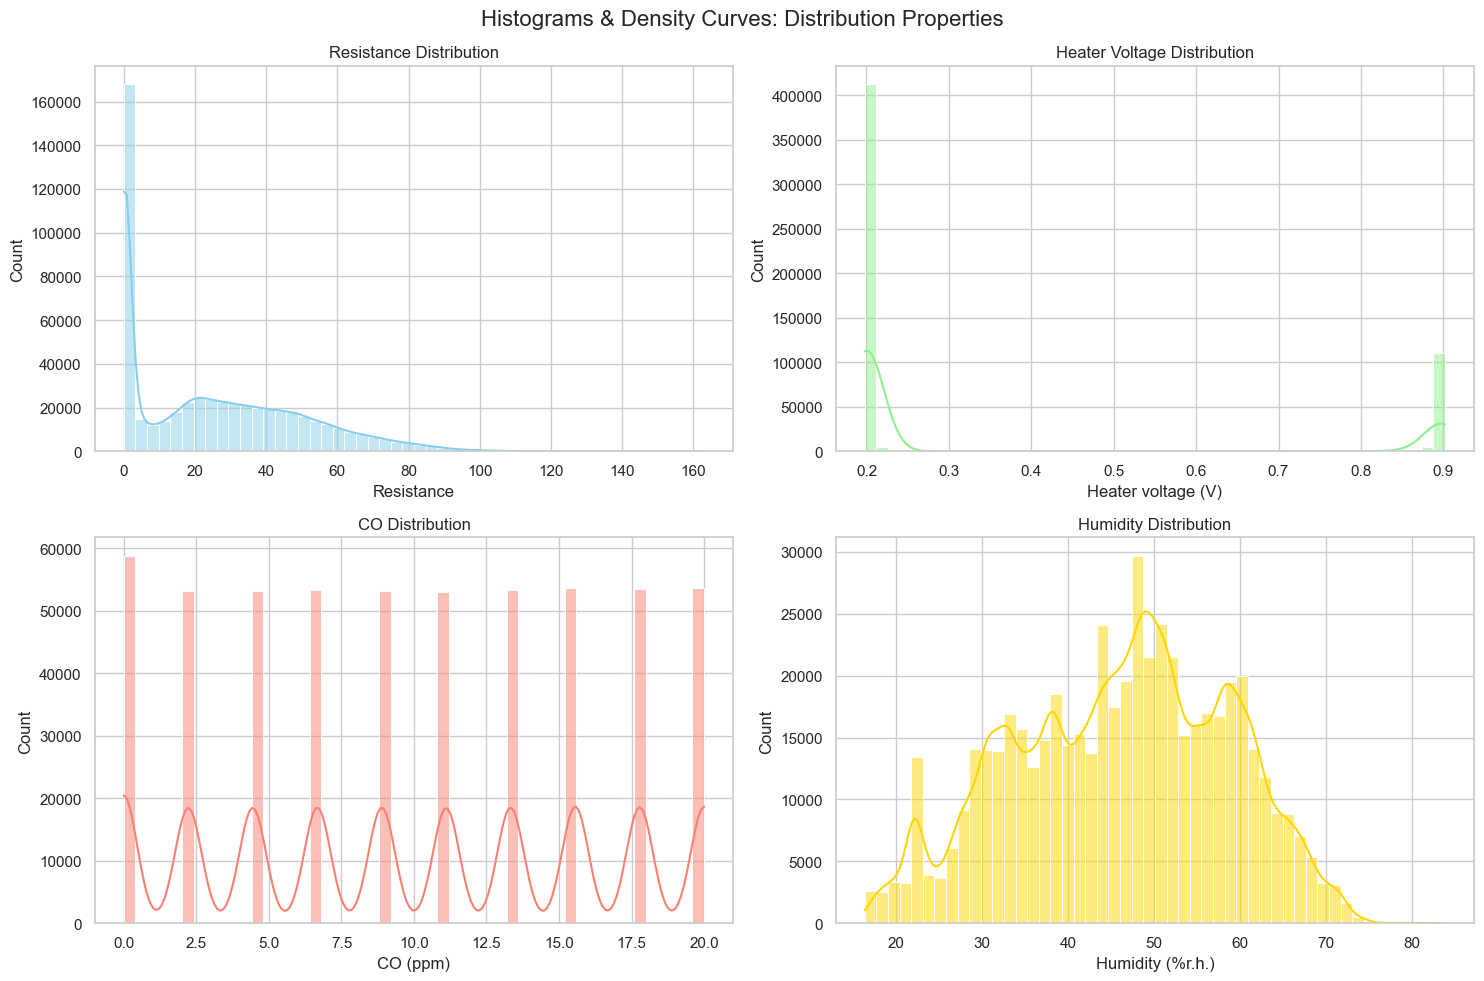

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Taking a 1% random sample")
df_sample = df_normalized.select(
    "Resistance", 
    "`Heater voltage (V)`", 
    "`CO (ppm)`", 
    "`Humidity (%r.h.)`"
).sample(fraction=0.01, seed=42).toPandas()

print("Sample ready! Plotting graphs...")

# Set plot style
sns.set_theme(style="whitegrid")

# Boxplots for Outlier Detection
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Boxplots: Outlier Detection", fontsize=16)

sns.boxplot(y=df_sample["Resistance"], ax=axes[0, 0], color="skyblue").set_title("Sensor Resistance")
sns.boxplot(y=df_sample["Heater voltage (V)"], ax=axes[0, 1], color="lightgreen").set_title("Heater Voltage")
sns.boxplot(y=df_sample["CO (ppm)"], ax=axes[1, 0], color="salmon").set_title("CO Concentration")
sns.boxplot(y=df_sample["Humidity (%r.h.)"], ax=axes[1, 1], color="gold").set_title("Humidity")

plt.tight_layout()
plt.show()

# Histograms & Density Curves
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Histograms & Density Curves: Distribution Properties", fontsize=16)

sns.histplot(df_sample["Resistance"], bins=50, kde=True, ax=axes[0, 0], color="skyblue").set_title("Resistance Distribution")
sns.histplot(df_sample["Heater voltage (V)"], bins=50, kde=True, ax=axes[0, 1], color="lightgreen").set_title("Heater Voltage Distribution")
sns.histplot(df_sample["CO (ppm)"], bins=50, kde=True, ax=axes[1, 0], color="salmon").set_title("CO Distribution")
sns.histplot(df_sample["Humidity (%r.h.)"], bins=50, kde=True, ax=axes[1, 1], color="gold").set_title("Humidity Distribution")

plt.tight_layout()
plt.show()